In [129]:
import numpy as np
import pandas as pd
from pyALRA import alra, normalize_data, choose_k
import scanpy as sc

from gene_trajectory.add_gene_bin_score import add_gene_bin_score
from gene_trajectory.coarse_grain import select_top_genes, coarse_grain_adata
from gene_trajectory.extract_gene_trajectory import get_gene_embedding, extract_gene_trajectory
from gene_trajectory.get_graph_distance import get_graph_distance
from gene_trajectory.gene_distance_shared import cal_ot_mat
from gene_trajectory.run_dm import run_dm
from gene_trajectory.plot.gene_trajectory_plots import plot_gene_trajectory_3d, plot_gene_trajectory_umap
from gene_trajectory.util.download_file import download_file_if_missing

from pathlib import Path
DATA_PATH = Path("/data3/projects/2025_GTRA/data/1_MND")

In [130]:
# scRNA-seq data
adata = sc.read_h5ad(DATA_PATH / "CCTSD_preproc.h5ad")
adata = adata[:,adata.var.highly_variable].copy()

In [131]:
k = choose_k(adata.X)

In [132]:
adata.layers['alra'] = alra(adata.X, k['k'])['A_norm_rank_k_cor_sc']

Read matrix with 6316 cells and 2000 genes
Find the 0.001 quantile of each gene
Sweep
Scaling all except for 0 columns
0.12% of the values became negative in the scaling process and were set to zero
The matrix went from 10.60% nonzero to 46.85% nonzero


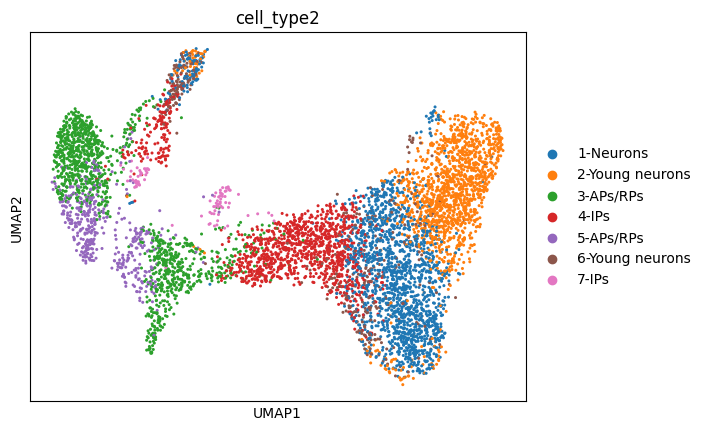

In [133]:
sc.pl.umap(adata, color=["cell_type2"])

### Gene-gene distance computation

In [134]:
genes = select_top_genes(adata, layer='counts', n_variable_genes=500)


In [135]:
run_dm(adata)
cell_graph_dist = get_graph_distance(adata, k=10)

In [136]:
gene_expression_updated, graph_dist_updated = coarse_grain_adata(adata, graph_dist=cell_graph_dist, features=genes, n=500)

In [137]:
gene_dist_mat = cal_ot_mat(gene_expr=gene_expression_updated, 
                           ot_cost=graph_dist_updated, 
                           show_progress_bar=True)

100%|██████████| 74691/74691 [00:05<00:00, 12892.25it/s]


#### Gene trajectory inference and visualization

In [138]:
gene_embedding, _ = get_gene_embedding(gene_dist_mat, k = 5)

In [139]:
gene_trajectory = extract_gene_trajectory(gene_embedding, gene_dist_mat, t_list = [4, 8, 7], gene_names=genes, k=5)

Early stop reached. 1 gene trajectories were retrieved.


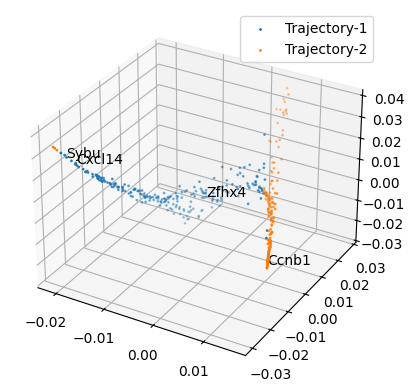

In [140]:
plot_gene_trajectory_3d(gene_trajectory, label_genes=['Ccnb1','Zfhx4','Sybu','Cxcl14'])


In [141]:
gene_trajectory

,DM_1,DM_2,DM_3,DM_4,DM_5,selected,Pseudoorder-1,Pseudoorder-2
Hba-a1,-0.011493,0.005039,-0.008417,0.002695,-0.007179,Trajectory-1,110.0,0.0
Fabp7,0.004827,0.013430,0.010239,-0.002548,-0.000691,Trajectory-1,215.0,0.0
Hbb-bs,-0.013609,0.001348,-0.007259,0.004366,-0.009852,Trajectory-1,87.0,0.0
Hbb-bt,-0.013275,0.002287,-0.008133,0.004445,-0.009585,Trajectory-1,90.0,0.0
Hbb-y,0.013161,-0.007850,-0.003919,-0.000450,0.000659,Trajectory-2,0.0,56.0
...,...,...,...,...,...,...,...,...
Kcne1l,-0.000583,0.013767,0.002963,0.002142,0.000090,Trajectory-1,187.0,0.0
Nkain4,-0.006216,0.010851,-0.007372,-0.001288,0.000137,Trajectory-1,162.0,0.0
Prokr2,-0.014184,-0.000112,-0.006476,0.004455,-0.009045,Trajectory-1,82.0,0.0
Sema5a,0.000416,0.012494,-0.000840,-0.005507,0.000933,Trajectory-1,195.0,0.0


#### Visulaize gene bin plots

In [142]:
adata

AnnData object with n_obs × n_vars = 6316 × 2000
    obs: 'Time_points', 'res.0.6', 'tSNE_1', 'tSNE_2', 'cell_type', 'cell_type2', 'timepoints', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'Time_points_colors', 'cell_type2_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_dm'
    varm: 'PCs'
    layers: 'counts', 'alra'
    obsp: 'connectivities', 'distances'

In [143]:
add_gene_bin_score(adata, gene_trajectory=gene_trajectory, n_bins=5, trajectories=1, layer='alra')

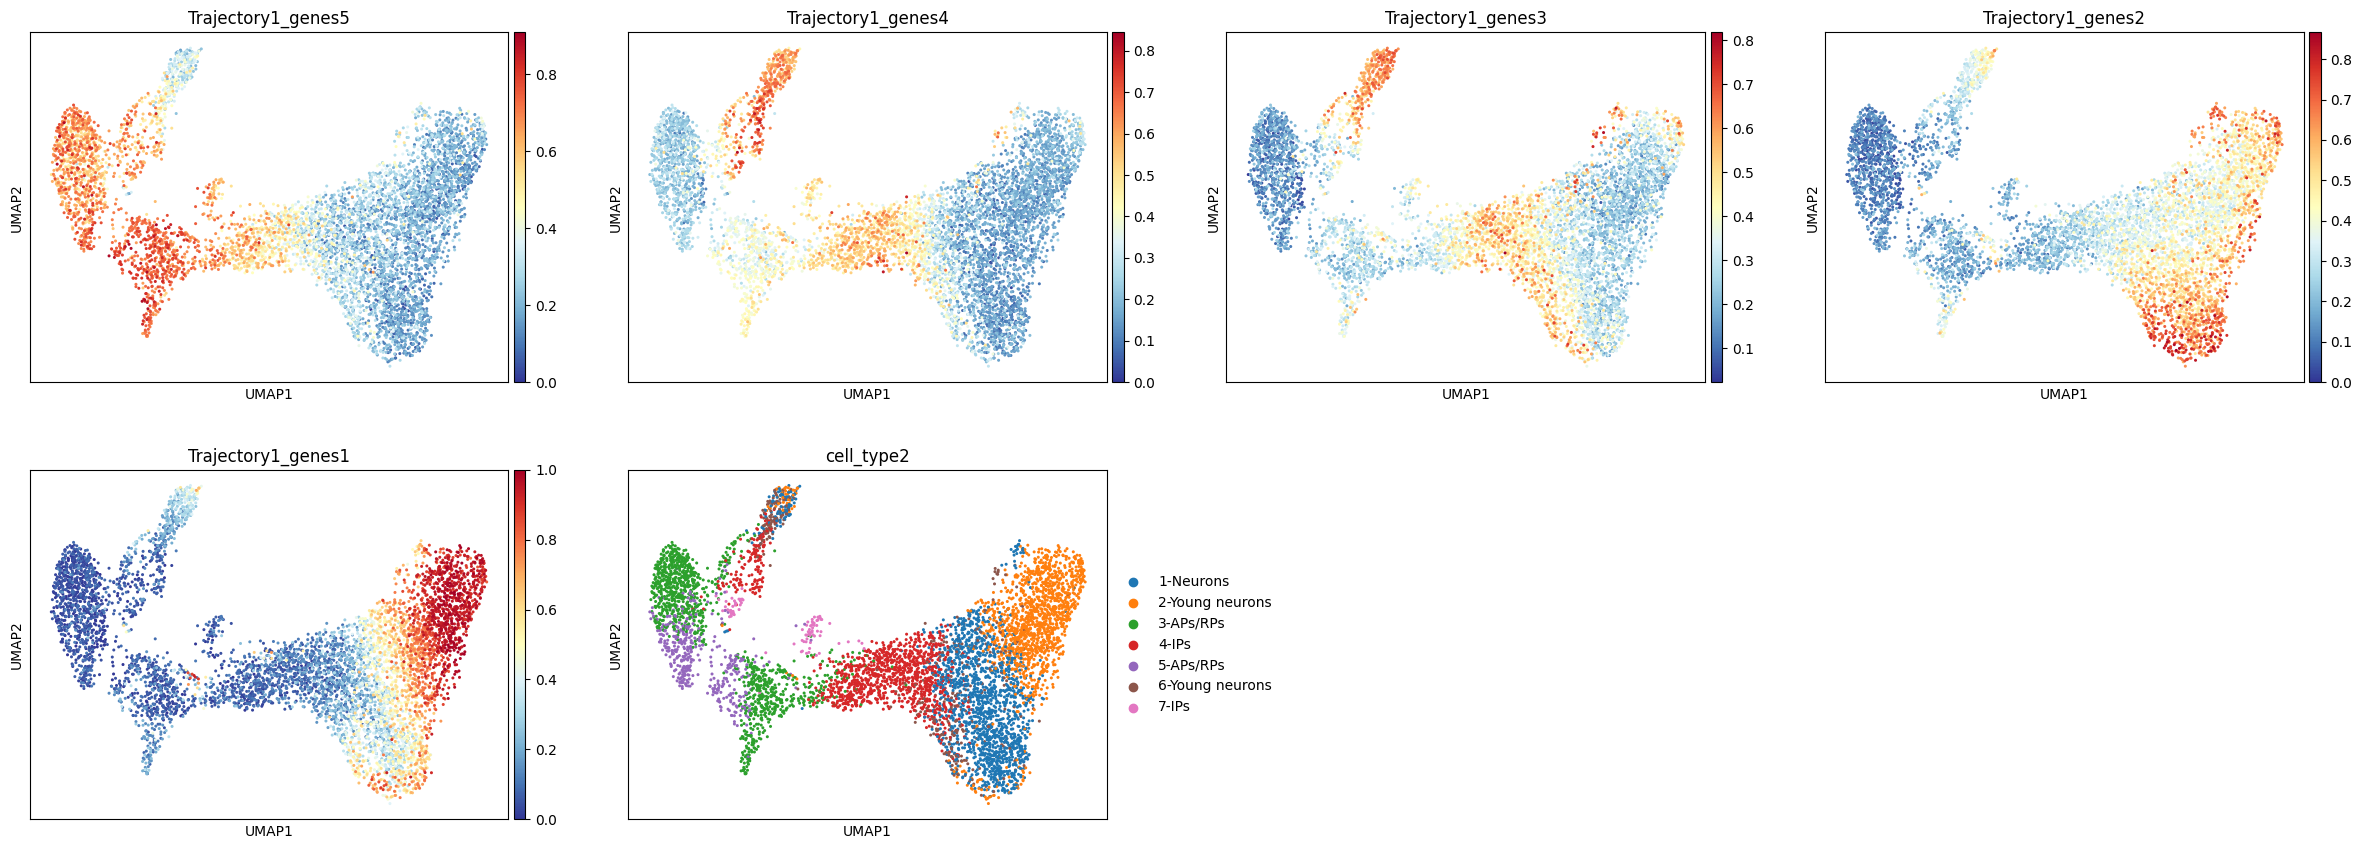

In [144]:
plot_gene_trajectory_umap(adata, 'Trajectory1', other_panels='cell_type2', reverse=True)


In [145]:
add_gene_bin_score(adata, gene_trajectory=gene_trajectory, n_bins=5, trajectories=2, layer='alra')

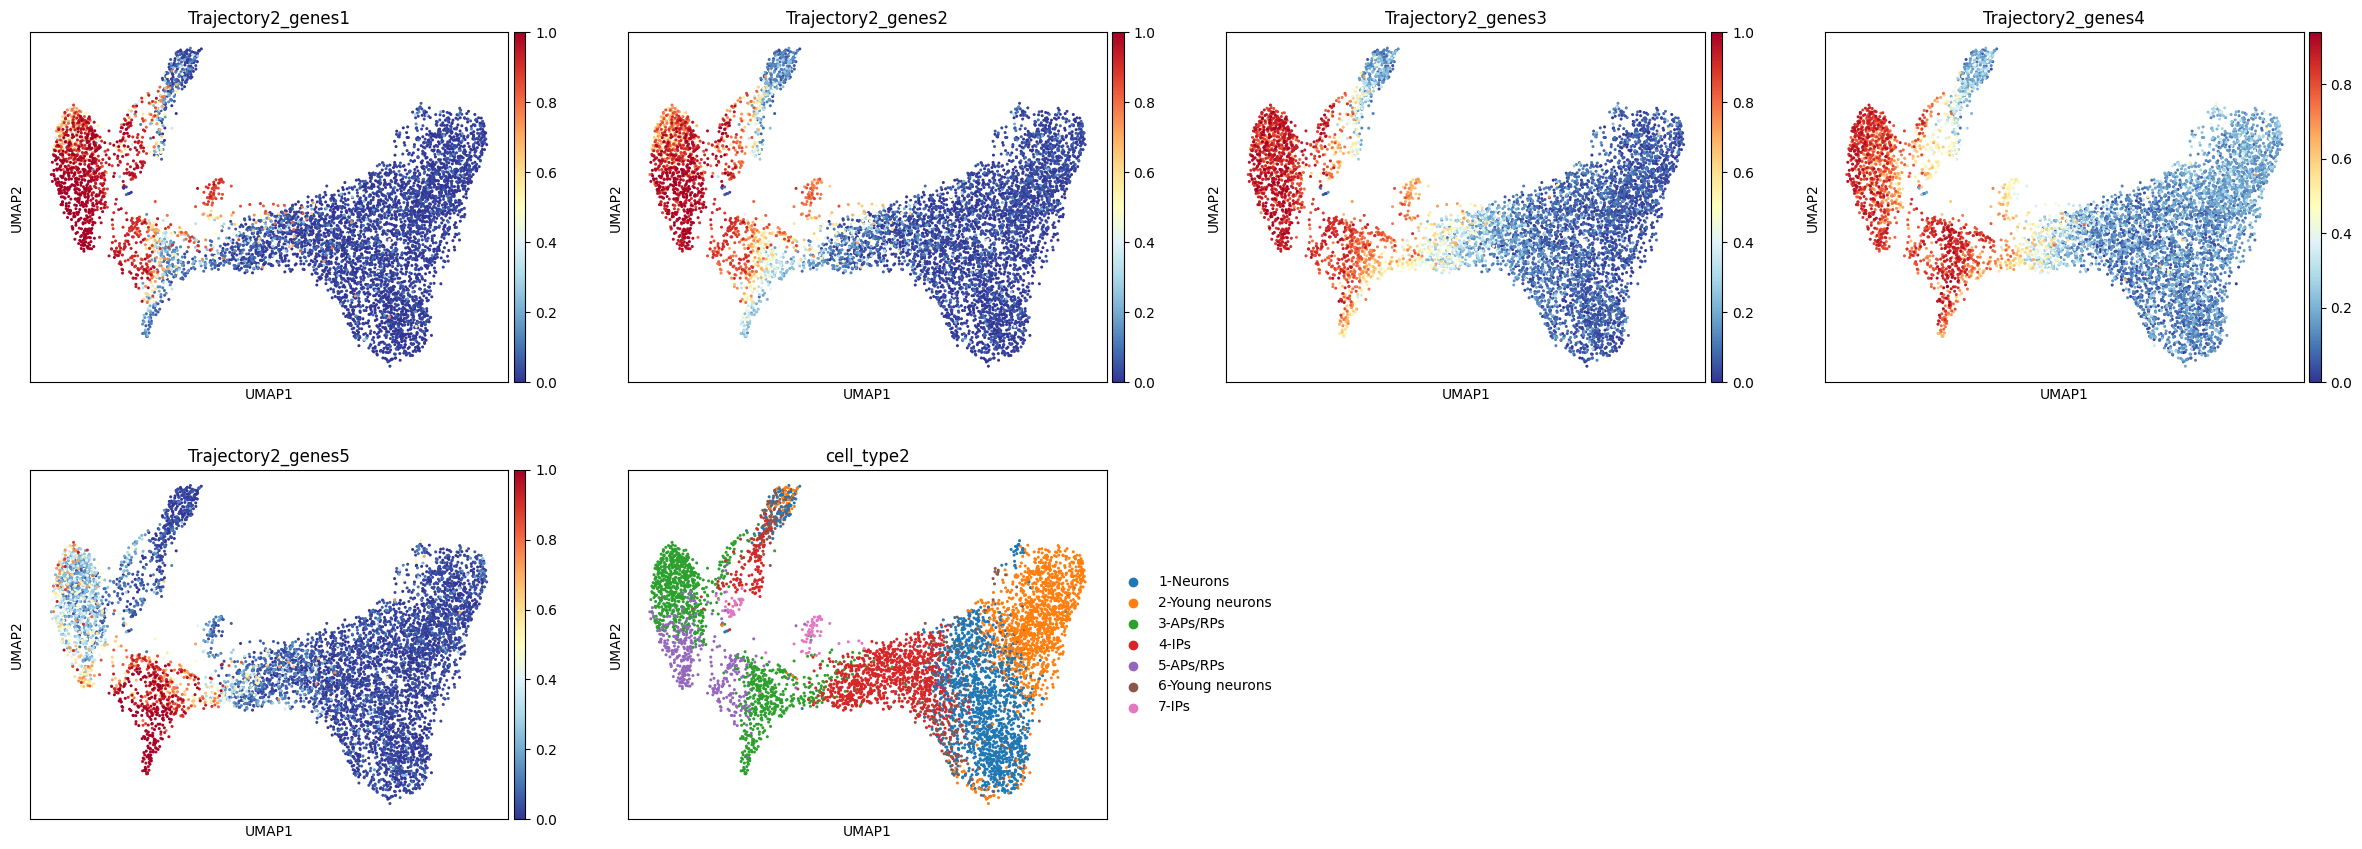

In [146]:
plot_gene_trajectory_umap(adata, 'Trajectory2', other_panels='cell_type2', reverse=False)


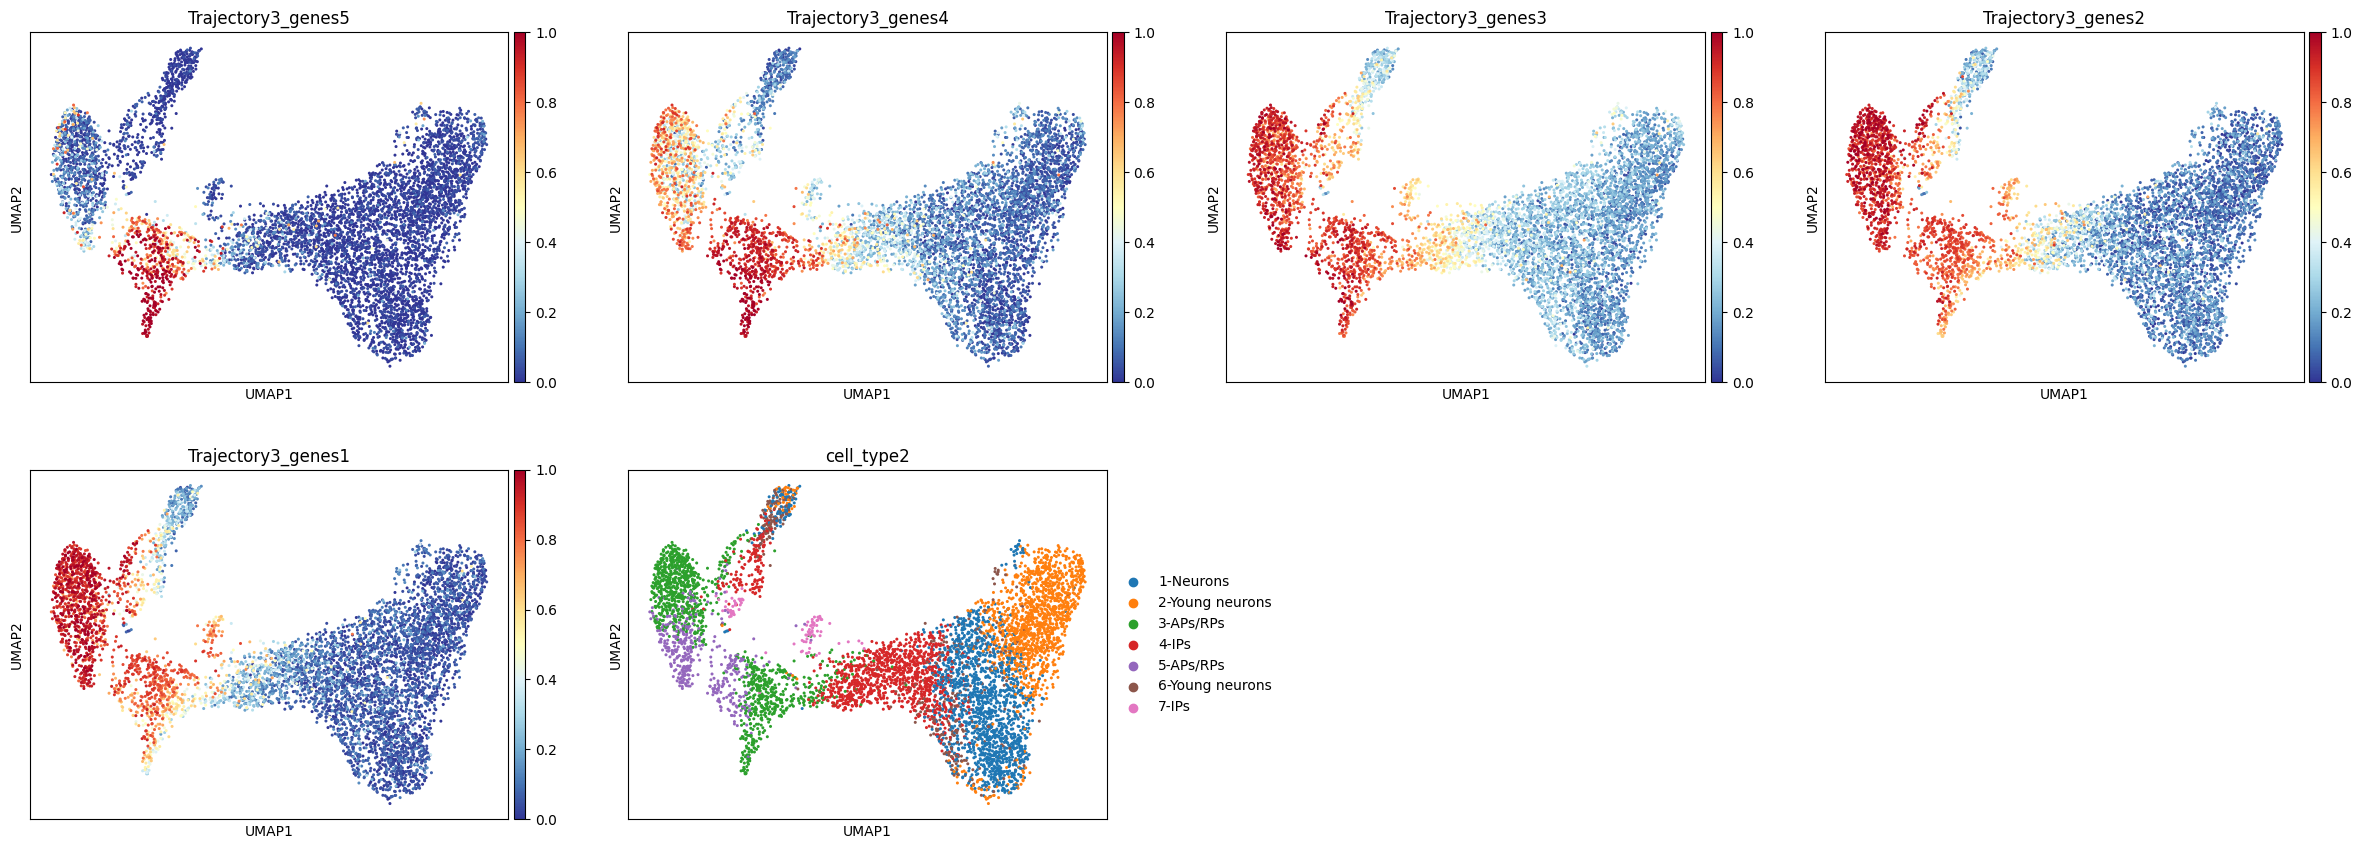

In [104]:
add_gene_bin_score(adata, gene_trajectory=gene_trajectory, n_bins=5, trajectories=3, layer='alra')
plot_gene_trajectory_umap(adata, 'Trajectory3', other_panels='cell_type2', reverse=True)


In [105]:
add_gene_bin_score(adata, gene_trajectory=gene_trajectory, n_bins=5, trajectories=4, layer='alra')
plot_gene_trajectory_umap(adata, 'Trajectory4', other_panels='cell_type2', reverse=True)


KeyError: 'Pseudoorder-4'

In [71]:
gt1 = gene_trajectory[gene_trajectory['selected'] == 'Trajectory-1']

In [72]:
adata.obs

,Time_points,res.0.6,tSNE_1,tSNE_2,cell_type,cell_type2,timepoints,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,Trajectory1_genes2,Trajectory1_genes3,Trajectory1_genes4,Trajectory1_genes5,Trajectory2_genes1,Trajectory2_genes2,Trajectory2_genes3,Trajectory2_genes4,Trajectory2_genes5,Trajectory1_genes6
TGATCAGCGCGG,e13,2,8.678596,23.826360,Young neurons,2-Young neurons,13,213,5.365976,541.0,...,0.405405,0.162162,0.081081,0.108108,0.000000,0.000000,0.030303,0.121212,0.00000,0.243243
GAAGCAGCCCGG,e15,2,-10.331985,18.746133,Young neurons,2-Young neurons,15,173,5.159055,445.0,...,0.378378,0.135135,0.108108,0.135135,0.000000,0.000000,0.060606,0.060606,0.00000,0.189189
CTGGTAGTGCCG,e15,2,-1.532774,15.829870,Young neurons,2-Young neurons,15,258,5.556828,867.0,...,0.513514,0.243243,0.189189,0.243243,0.030303,0.000000,0.030303,0.090909,0.00000,0.135135
TGGTAGTGAGAT,e15,1,6.045770,13.475845,Neurons,1-Neurons,15,222,5.407172,611.0,...,0.513514,0.351351,0.162162,0.162162,0.000000,0.030303,0.030303,0.060606,0.00000,0.135135
ATTGCGGCGGGG,e11,3,-20.223722,-7.906668,APs/RPs,3-APs/RPs,11,256,5.549076,431.0,...,0.216216,0.243243,0.459459,0.567568,0.909091,0.878788,0.939394,0.787879,0.15625,0.540541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AAATTTAAACAG,e11,3,-14.613337,-22.714780,APs/RPs,3-APs/RPs,11,301,5.710427,576.0,...,0.162162,0.081081,0.081081,0.324324,1.000000,1.000000,0.939394,0.818182,0.21875,0.594595
CACGGCAAGTTG,e13,4,14.781250,-21.210181,IPs,4-IPs,13,200,5.303305,434.0,...,0.297297,0.270270,0.432432,0.675676,0.000000,0.030303,0.242424,0.212121,0.03125,0.351351
AAGTTCCGAGAA,e15,4,9.348971,-5.646222,IPs,4-IPs,15,131,4.882802,256.0,...,0.270270,0.513514,0.270270,0.189189,0.030303,0.000000,0.030303,0.030303,0.00000,0.162162
CACCTTTGCGGA,e13,4,6.898789,-23.437853,IPs,4-IPs,13,209,5.347108,544.0,...,0.216216,0.189189,0.216216,0.621622,0.030303,0.090909,0.484848,0.424242,0.09375,0.486486


In [80]:
for i in gt1.sort_values('Pseudoorder-1', ascending=True)[['Pseudoorder-1']].head(50).index:
    print(i)
    

Sybu
Nfe2l3
Syt6
Arhgap20
Ppp1r1b
Cdh13
Dync1i1
Cxcl14
Brinp1
Nin
Sla
Camk2b
Prkce
B3gat1
Mef2c
Gria3
Tenm2
Rspo3
Lmo3
Zfp804a
Ldb2
Sparcl1
Lypd1
Ina
Kitl
Tenm1
Syt1
Rorb
Mapt
Cck
Lpl
Arhgef28
Nrxn1
Islr2
Atp1b1
Npy
S100a10
Snca
Nap1l5
Gucy1a3
Runx1t1
Sox5
Bcl11b
Fezf2
Meg3
Tle4
Dner
Ppp1r14c
March1
Pcdhb7


In [31]:
adata.obs

,Time_points,res.0.6,tSNE_1,tSNE_2,cell_type,cell_type2,timepoints,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,Trajectory1_genes1,Trajectory1_genes2,Trajectory1_genes3,Trajectory1_genes4,Trajectory1_genes5,Trajectory2_genes1,Trajectory2_genes2,Trajectory2_genes3,Trajectory2_genes4,Trajectory2_genes5
TGATCAGCGCGG,e13,2,8.678596,23.826360,Young neurons,2-Young neurons,13,213,5.365976,541.0,...,0.333333,0.111111,0.000000,0.044444,0.022727,0.000000,0.000000,0.030303,0.090909,0.0000
GAAGCAGCCCGG,e15,2,-10.331985,18.746133,Young neurons,2-Young neurons,15,173,5.159055,445.0,...,0.377778,0.111111,0.045455,0.022222,0.090909,0.000000,0.000000,0.030303,0.000000,0.0000
CTGGTAGTGCCG,e15,2,-1.532774,15.829870,Young neurons,2-Young neurons,15,258,5.556828,867.0,...,0.377778,0.155556,0.090909,0.066667,0.068182,0.030303,0.000000,0.030303,0.060606,0.0000
TGGTAGTGAGAT,e15,1,6.045770,13.475845,Neurons,1-Neurons,15,222,5.407172,611.0,...,0.200000,0.155556,0.090909,0.044444,0.068182,0.000000,0.030303,0.030303,0.030303,0.0000
ATTGCGGCGGGG,e11,3,-20.223722,-7.906668,APs/RPs,3-APs/RPs,11,256,5.549076,431.0,...,0.044444,0.111111,0.181818,0.200000,0.227273,0.181818,0.333333,0.393939,0.333333,0.0625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AAATTTAAACAG,e11,3,-14.613337,-22.714780,APs/RPs,3-APs/RPs,11,301,5.710427,576.0,...,0.066667,0.111111,0.022727,0.066667,0.340909,0.424242,0.393939,0.545455,0.272727,0.1250
CACGGCAAGTTG,e13,4,14.781250,-21.210181,IPs,4-IPs,13,200,5.303305,434.0,...,0.044444,0.088889,0.068182,0.288889,0.090909,0.000000,0.000000,0.151515,0.090909,0.0000
AAGTTCCGAGAA,e15,4,9.348971,-5.646222,IPs,4-IPs,15,131,4.882802,256.0,...,0.066667,0.111111,0.113636,0.022222,0.090909,0.000000,0.000000,0.000000,0.030303,0.0000
CACCTTTGCGGA,e13,4,6.898789,-23.437853,IPs,4-IPs,13,209,5.347108,544.0,...,0.044444,0.066667,0.022727,0.111111,0.204545,0.030303,0.060606,0.212121,0.212121,0.0000
